# Parkflächen umverteilen

## Daten aufbereiten

### Parkflächen ermitteln
Quelle: Flächenmehrzweckkarte (FMZK) der Stadt Wien (https://www.data.gv.at/katalog/dataset/7cf0da04-1f77-4321-929e-78172c74aa0b)  
Stand: 15. Oktober 2024

Die FMZK enthält fehlerhafte Einträge:

```geopandas.read_file("fmzk.gpkg")```

```GEOSException: IllegalArgumentException: point array must contain 0 or >1 elements```

Umweg über QGIS:
* FMZK Geopackage importieren
* Layer filtern nach ```"F_KLASSE_TEXT" = "Ruhender Verkehr"```
* Layer CRS auf *EPSG: 31256* setzen
* Gefilterte Layer ohne Metadaten als Geopackage exportieren

<Axes: >

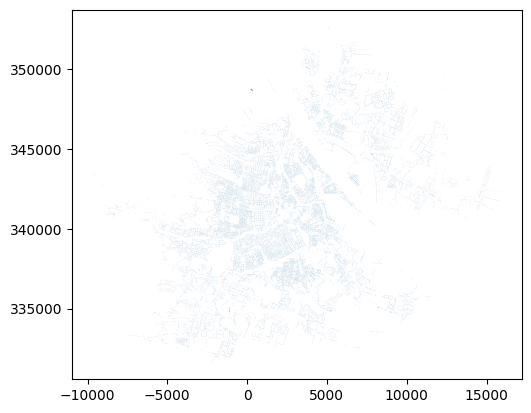

In [17]:
import geopandas as gpd

parkflaechen = gpd.read_file("parkflaechen_wien.gpkg")
parkflaechen.plot()

### Parkflächen in einzelne Parkplätze aufteilen

#### Largest interior rectangles finden
Parkflächen sind oft wenig rechtecksähnlich und können Löcher enthalten (z.B. Baumscheiben).  
Für die Aufteilung in einzelne Parkplätze zunächst die Parkflächen-Polygone mit möglichst großen Rechtecken füllen.  
Dafür gibts folgendes Package: https://github.com/OpenStitching/lir

Herausforderungen:
1. **Das LIR-Package findet nur axis-aligned LIRs**  
Parkflächen-Polygone sind beliebig orientiert
2. **Das LIR-Package repräsentiert den Polygon intern als binary grid**  
Parkflächen-Polygone liegen als Gleitkomma EPSG:31256-Koordinaten vor. Skalierung auf Ganzzahlen erfordert zu großes grid.

Lösungen:
1. Axis-alignment
    1. Minimum-Bounding-Rectangle (MBR) für Parkflächen-Polygon berechnen
    2. Winkel zwischen MBR und x-Achse berechnen
    3. Parkflächen-Polygon um berechneten Winkel rotieren
    4. LIR berechnen und zurückrotieren um Schwerpunkt des Originalpolygons
2. Koordinatensystem
    1. EPSG:31256-Koordinaten des Polygon offsetten um Minimalkoordinate des Polygon
    2. Normalisierte Koordinaten skalieren und runden, Genauigkeit von 10cm (resolution=0.1) ausreichend
    3. LIR berechnen und zurückskalieren bzw. -offsetten auf EPSG:31256-Koordinaten

Gefundenes LIR von Parkflächen-Polygon abschneiden und Algorithmus erneut anwenden bis LIR kleiner als 2x6 bzw. 5x6 Meter. 
2 Meter ist eigentlich zu schmal für einen Parkplatz aber im Falle eines gekrümmten Parkflächen-Polygons sind die gefundenen LIRs stets schmäler als die originale Parkfläche.

Die meisten Parkflächen sind eh rechteckig - eine zweite, zeitintensive LIR-Berechnung nur anstarten wenn restliche Fläche groß genug für weiteren Parkplatz (ca. 12qm)

In [18]:
import numpy as np
import math
from shapely.geometry import MultiPolygon, box
from shapely import affinity
import largestinteriorrectangle as lir
from matplotlib import pyplot as plt

def align_to_xaxis(poly):
    # Get the minimum area bounding rectangle (already axis-aligned)
    min_rect = poly.minimum_rotated_rectangle

    # Get the coordinates of the bounding rectangle
    rect_coords = list(min_rect.exterior.coords)

    # Ensure we have at least 4 unique points
    if len(rect_coords) < 5:
        raise ValueError("Bounding rectangle does not have enough points")

    # Extract the first two distinct points to compute orientation
    x1, y1 = rect_coords[0]
    x2, y2 = rect_coords[1]

    # Compute the angle between the first edge and the x-axis
    angle = -math.degrees(math.atan2(y2 - y1, x2 - x1))

    # Rotate the polygon to align with the x-axis
    centroid = poly.centroid.coords[0]  # Store centroid before rotation
    rotated_poly = affinity.rotate(poly, angle, origin=centroid, use_radians=False)

    return rotated_poly, angle, centroid


def normalize(poly, resolution):
    minx, miny, _, _ = poly.bounds  # Get bounding box

    # Get exterior coordinates of the polygon
    coords = np.array(poly.exterior.coords)

    # Offset coordinates by subtracting minx, miny
    coords[:, 0] -= minx  # Adjust X-coordinates
    coords[:, 1] -= miny  # Adjust Y-coordinates

    # Round to the nearest resolution and convert to integer grid
    coords = (coords / resolution).round().astype(np.int32)

    # Reshape to 3D array with shape (1, n, 2)
    coords = coords[np.newaxis, :, :]  # Adds the extra dimension

    return coords, (minx, miny)


def denormalize(rect, offset, resolution):
    x_normalized, y_normalized, width_normalized, height_normalized = rect
    minx, miny = offset

    x = x_normalized * resolution + minx
    y = y_normalized * resolution + miny
    width = width_normalized * resolution
    height = height_normalized * resolution

    # Compute max x and y
    maxx = x + width
    maxy = y + height

    return box(x, y, maxx, maxy)


def compute_all_lirs(parking_lane_polygon, min_dim1=2, min_dim2=5, resolution=0.1):
    # Step 1: Rotate the polygon to be axis aligned.
    rotated_poly, angle, centroid = align_to_xaxis(parking_lane_polygon)
    
    polys_queue = [rotated_poly]  # Work in rotated space
    found_lirs = []
    
    while polys_queue:
        current_poly = polys_queue.pop()

        # Step 2: Normalize the polygon coordinates.
        normalized_poly, offset = normalize(current_poly, resolution)
        
        # Step 3: Run the LIR algorithm on the normalized polygon. (Assuming lir.lir returns [x, y, w, h] in grid cells.)
        lir_normalized_rect = lir.lir(normalized_poly)
        if lir_normalized_rect is None:
            continue  # No LIR found
        
        # Step 4: Convert the normalized rectangle to a polygon in EPSG:31256 coordinates.
        lir_rotated = denormalize(lir_normalized_rect, offset, resolution)
        
        # Step 5: Check if the rectangle meets the minimum size criteria.
        lx, ly, ux, uy = lir_rotated.bounds
        width = ux - lx
        height = uy - ly
        if not ((width >= min_dim1 and height >= min_dim2) or (width >= min_dim2 and height >= min_dim1)):
            continue
        
        # Accept this LIR.
        found_lirs.append(lir_rotated)
        
        # Step 6: Subtract the found LIR from the current polygon.
        new_poly = current_poly.difference(lir_rotated)
        if new_poly.is_empty or new_poly.area < 10:
            continue
        
        if isinstance(new_poly, MultiPolygon):
          polys_queue.extend(list(new_poly.geoms))
        else:
          polys_queue.append(new_poly)
    
    # Step 7: Rotate all found LIRs back to the original coordinate system.
    final_lirs = [affinity.rotate(lir_, -angle, origin=centroid, use_radians=False) for lir_ in found_lirs]
    return final_lirs


parkflaechen_lirs = parkflaechen['geometry'].head(50).apply(compute_all_lirs)
parkflaechen_lirs = [lir for sublist in parkflaechen_lirs for lir in sublist]
parkflaechen_lirs = gpd.GeoDataFrame({'geometry': parkflaechen_lirs}, crs=parkflaechen.crs)
print(parkflaechen_lirs)

                                             geometry
0   POLYGON ((6510.975 336947.187, 6512.804 336948...
1   POLYGON ((7971.265 345421.639, 7973.261 345420...
2   POLYGON ((5881.517 349607.151, 5883.869 349606...
3   POLYGON ((5840.555 349612.485, 5839.664 349610...
4   POLYGON ((5858.849 349604.778, 5858.003 349602...
5   POLYGON ((147.155 336776.047, 149.365 336775.4...
6   POLYGON ((3916.101 334995.738, 3915.047 334994...
7   POLYGON ((3930.855 334263.907, 3932.827 334263...
8   POLYGON ((-995.22 336362.607, -994.42 336364.4...
9   POLYGON ((-1076.658 336393.162, -1077.497 3363...
10  POLYGON ((2321.177 342140.975, 2322.112 342138...
11  POLYGON ((-1139.44 336215.608, -1137.081 33621...
12  POLYGON ((4175.641 348020.744, 4171.865 348021...
13  POLYGON ((8482.187 345651.645, 8480.553 345648...
14  POLYGON ((9614.911 346126.23, 9613.896 346124....
15  POLYGON ((9571.176 346146.6, 9570.162 346144.4...
16  POLYGON ((6822.79 343211.234, 6826.133 343214....
17  POLYGON ((6762.563 34328

#### LIRs in Parkplätze aufteilen

In [19]:
def split_parkflaeche(poly, min_parallel=6, min_perp=3):
    """
    Split a rectangular parking lane polygon into subrectangles (parking spots).
    
    Parameters:
      poly         : shapely Polygon (assumed to be a rectangle with 4 vertices)
      min_parallel : minimum spot length (m) for a parallel parking lane (if lane width < 3 m)
      min_perp     : minimum spot length (m) for a perpendicular parking lane (if lane width >= 3 m)
      
    Returns:
      A list of shapely Polygons corresponding to the individual parking spots.
    """
    # Get the 4 unique vertices (ignore the closing coordinate which equals the first)
    coords = list(poly.exterior.coords)[:-1]
    if len(coords) != 4:
        raise ValueError("Polygon does not have 4 vertices!")
    
    # Helper function to compute Euclidean distance
    def dist(a, b):
        return math.hypot(b[0]-a[0], b[1]-a[1])
    
    # Compute the lengths of the first two edges.
    d0 = dist(coords[0], coords[1])
    d1 = dist(coords[1], coords[2])
    
    # Decide which edge is the “length” (longer side)
    if d0 >= d1:
        # Use the vector from coords[0] to coords[1] for orientation
        dx = coords[1][0] - coords[0][0]
        dy = coords[1][1] - coords[0][1]
    else:
        # Use the vector from coords[1] to coords[2] for orientation
        dx = coords[2][0] - coords[1][0]
        dy = coords[2][1] - coords[1][1]
    
    # Calculate the angle (in degrees) of the long side relative to the x-axis.
    theta = math.degrees(math.atan2(dy, dx))
    
    # Rotate the polygon so that the long side is horizontal.
    # We use the polygon’s centroid as the rotation center.
    cen = poly.centroid
    poly_rot = affinity.rotate(poly, -theta, origin=cen)
    
    # Get the bounds of the rotated polygon.
    minx, miny, maxx, maxy = poly_rot.bounds
    L_aligned = maxx - minx  # This is the (rotated) length
    W_aligned = maxy - miny  # This is the (rotated) width
    
    # Determine the type of parking lane based on the lane’s width:
    # if width < 3 m → parallel parking (min spot length = 5 m)
    # else → perpendicular parking (min spot length = 3.5 m)
    req = min_parallel if W_aligned < 3 else min_perp
    
    # Compute the number of spots that fit (each gets at least req meters)
    n = int(math.floor(L_aligned / req))
    # (Make sure we have at least one spot.)
    n = max(n, 1)
    
    # Now, each spot will actually be L_aligned/n long so that any extra length is equally shared.
    spot_len = L_aligned / n
    
    spots = []
    # For each spot, build a subrectangle in the rotated coordinate system.
    for i in range(n):
        # The lower-left corner of the i-th spot:
        ll = (minx + i * spot_len, miny)
        ur = (minx + (i + 1) * spot_len, maxy)
        subrect = box(*ll, *ur)
        # Rotate the subrectangle back to the original coordinate system.
        subrect_orig = affinity.rotate(subrect, theta, origin=cen)
        spots.append(subrect_orig)
    
    return spots


parkplaetze = parkflaechen_lirs['geometry'].apply(split_parkflaeche)
parkplaetze = [lir for sublist in parkplaetze for lir in sublist]
parkplaetze = gpd.GeoDataFrame({'geometry': parkplaetze}, crs=parkflaechen.crs)
print(parkplaetze)

                                              geometry
0    POLYGON ((6509.34 336953.592, 6507.511 336952....
1    POLYGON ((6505.876 336958.774, 6504.047 336957...
2    POLYGON ((6502.412 336963.956, 6500.583 336962...
3    POLYGON ((7976.666 345425.398, 7974.67 345426....
4    POLYGON ((7980.07 345430.491, 7978.075 345431....
..                                                 ...
181  POLYGON ((-3236.983 334196.622, -3237.847 3341...
182  POLYGON ((-3375.448 334236.098, -3377.453 3342...
183  POLYGON ((-3489.102 334234.079, -3487.139 3342...
184  POLYGON ((-3491.285 334228.33, -3489.322 33422...
185  POLYGON ((-3101.331 334159.612, -3100.94 33416...

[186 rows x 1 columns]


In [20]:
parkflaechen_lirs.to_crs(epsg=3857).to_file("lirs.gpkg", driver="GPKG")
parkplaetze.to_crs(epsg=3857).to_file("parkplaetze.gpkg", driver="GPKG")